In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control 

In [4]:
def define_parameters():
    params = {'A1': 1,'A2': 1,  'A3': 1,'R2': 1.5,'R3': 1.0,'R4': 1.0,'R5': 1.0}
    return params

In [ ]:

def create_system(params):
    A1 = params['A1']
    A2 = params['A2']
    A3 = params['A3']
    R2 = params['R2']
    R3 = params['R3']
    R4 = params['R4']
    R5 = params['R5']
    A_full = np.array([[-1/A1 * (1/R2 - 1/R3), 0, 0],[1/(A2*R2), -1/(R4*A2), 0],[1/(A3*R3), 0, -1/(A3*R5)]])
    B_full = np.array([[1/A1], [0], [0]])
    C_full = np.array([[0, 1, 0], [0, 0, 1]])
    D_full = np.zeros((2, 1))
    ss_sys = control.ss(A_full, B_full, C_full, D_full)
    print("State Space System:")
    print(ss_sys)

    return ss_sys

In [7]:
params = define_parameters()
sys = create_system(params)
poles = np.linalg.eigvals(sys.A)
print("System poles:", poles)
print("System stability:", "Stable" if all(np.real(poles) < 0) else "Unstable")

State Space System:
<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (2): ['y[0]', 'y[1]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[ 0.33333333  0.          0.        ]
     [ 0.66666667 -1.          0.        ]
     [ 1.          0.         -1.        ]]

B = [[1.]
     [0.]
     [0.]]

C = [[0. 1. 0.]
     [0. 0. 1.]]

D = [[0.]
     [0.]]
System poles: [-1.         -1.          0.33333333]
System stability: Unstable


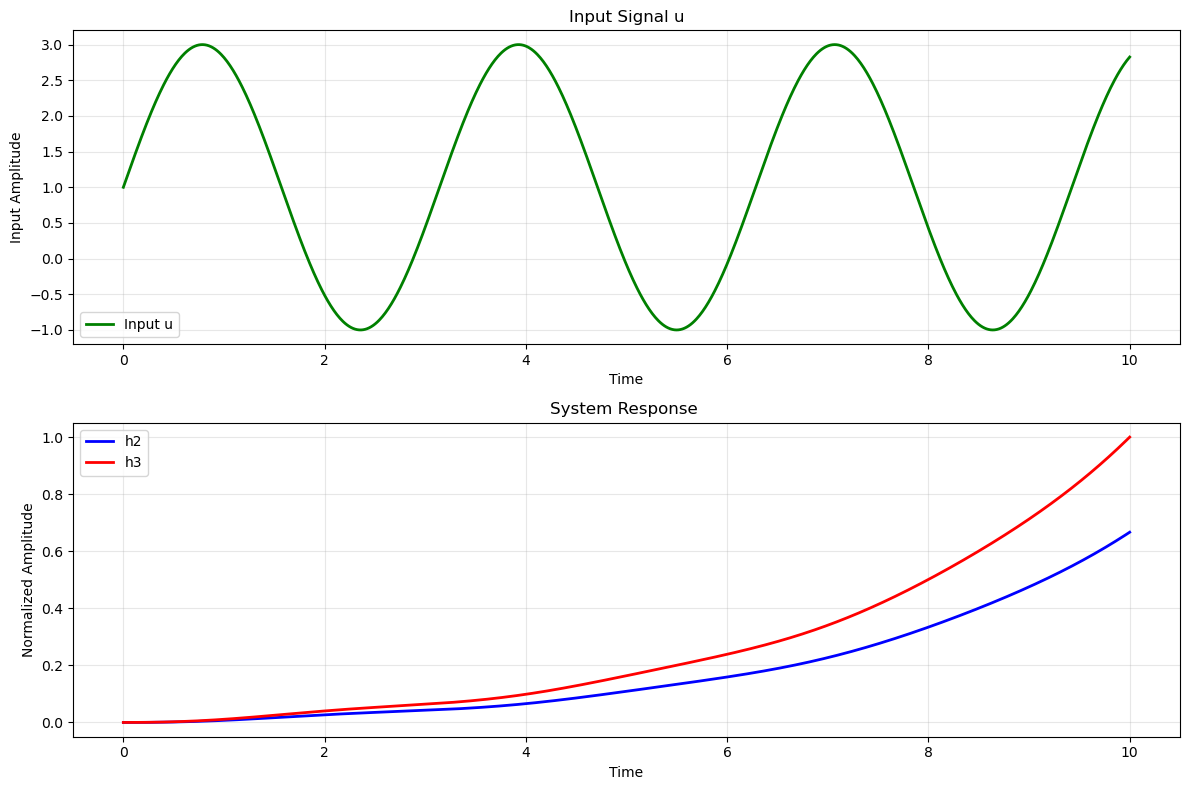

In [22]:
t = np.linspace(0, 10, 1000) 
u_step = np.ones_like(t)
u_ramp = 0.5 * t
u_sin = 2 * np.sin(2 * t) + 1
u_custom = np.where(t < 2, 0,    np.where(t < 5, 1.5,    np.where(t < 8, 0.5, 2.0)))
u = u_sin
t_out, y_out = control.forced_response(sys, T=t, U=u)
u_normalized = u / np.max(np.abs(u)) if np.max(np.abs(u)) != 0 else u
y_normalized = y_out / np.max(np.abs(y_out)) if np.max(np.abs(y_out)) != 0 else y_out
plt.figure(figsize=(12, 8))

# Plot input signal
plt.subplot(2, 1, 1)
plt.plot(t, u, 'g-', linewidth=2, label='Input u')
plt.xlabel('Time')
plt.ylabel('Input Amplitude')
plt.title('Input Signal u')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot normalized outputs
plt.subplot(2, 1, 2)
plt.plot(t_out, y_normalized[0], 'b-', linewidth=2, label='h2')
plt.plot(t_out, y_normalized[1], 'r-', linewidth=2, label='h3')
plt.xlabel('Time')
plt.ylabel('Normalized Amplitude')
plt.title('System Response ')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


c:\Users\CorteC\anaconda3\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


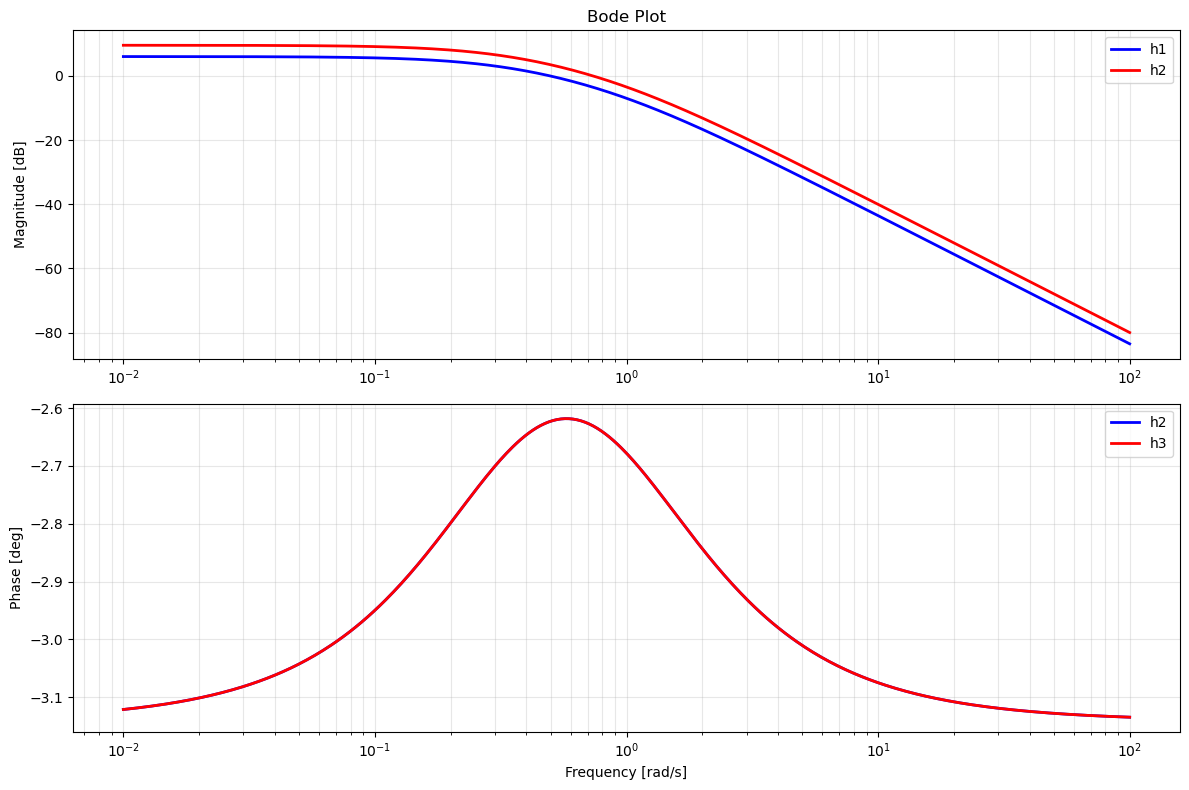

In [23]:
plt.figure(figsize=(12, 8))
omega = np.logspace(-2, 2, 500) 

mag1, phase1, omega1 = control.bode(sys[0, 0], omega, dB=True, deg=True,  label='Output 1', plot=False)
mag2, phase2, omega2 = control.bode(sys[1, 0], omega, dB=True, deg=True, label='Output 2', plot=False)

# Plot magnitude subplot
plt.subplot(2, 1, 1)
plt.semilogx(omega1, 20*np.log10(mag1), 'b-', linewidth=2, label='h1')
plt.semilogx(omega2, 20*np.log10(mag2), 'r-', linewidth=2, label='h2')
plt.ylabel('Magnitude [dB]')
plt.title('Bode Plot')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

# Plot phase subplot
plt.subplot(2, 1, 2)
plt.semilogx(omega1, phase1, 'b-', linewidth=2, label='h2')
plt.semilogx(omega2, phase2, 'r-', linewidth=2, label='h3')
plt.ylabel('Phase [deg]')
plt.xlabel('Frequency [rad/s]')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
tf_sys = control.ss2tf(sys)
print(tf_sys)
G1 = tf_sys[0, 0]  
G2 = tf_sys[1, 0] 

<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (2): ['y[0]', 'y[1]']

Input 1 to output 1:

           0.6667 s + 0.6667
  -----------------------------------
  s^3 + 1.667 s^2 + 0.3333 s - 0.3333

Input 1 to output 2:

                 s + 1
  -----------------------------------
  s^3 + 1.667 s^2 + 0.3333 s - 0.3333



PID Parameters for G1: Kp=2.0, Ki=1.0, Kd=0.6
Closed-loop poles for G1: [-99.59571056+0.j          -0.1196979 +0.88917518j
  -0.1196979 -0.88917518j  -1.        +0.j
  -0.83156032+0.j        ]
Closed-loop stability: Stable


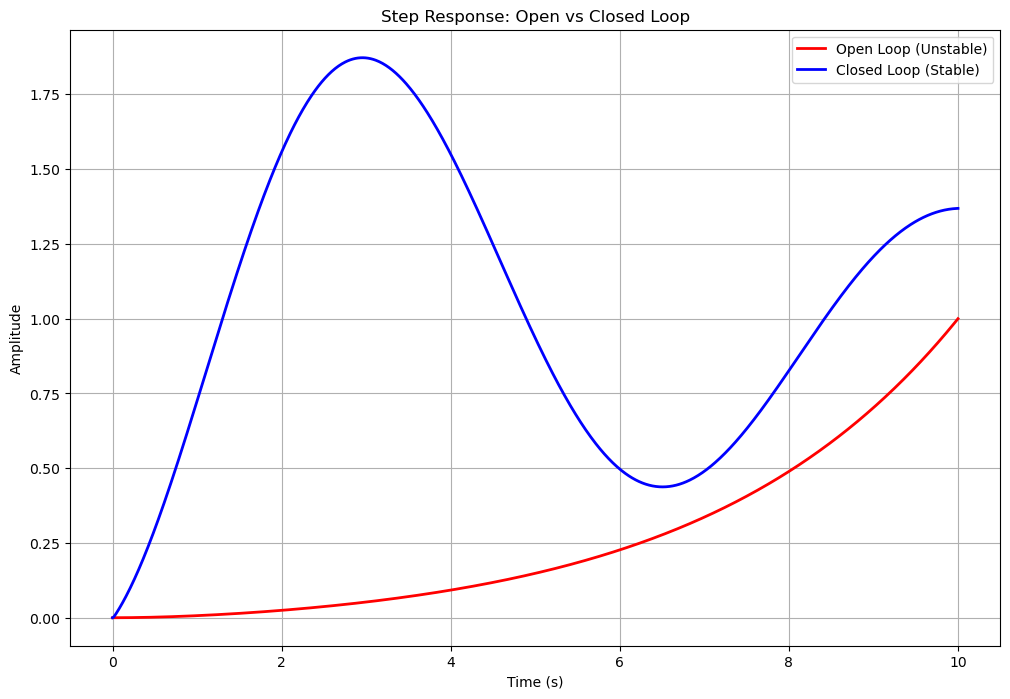

In [21]:

def create_pid(Kp, Ki, Kd, Tf=0.01):
    s = control.tf('s')
    pid = Kp + Ki/s + Kd*s/(Tf*s + 1)
    return pid

Kp1, Ki1, Kd1 = 2.0, 1.0, 0.6
pid1 = create_pid(Kp1, Ki1, Kd1)
closed_loop1 = control.feedback(pid1 * G1, 1)

print(f"\nPID Parameters for G1: Kp={Kp1}, Ki={Ki1}, Kd={Kd1}")
print("Closed-loop poles for G1:", control.poles(closed_loop1))
print("Closed-loop stability:", "Stable" if is_system_stable(closed_loop1) else "Unstable")


plt.figure(figsize=(12, 8))
t_open, y_open = control.step_response(G1, T=np.linspace(0, 10, 1000))
t_closed, y_closed = control.step_response(closed_loop1, T=np.linspace(0, 10, 1000))
y_normalized = y_open / np.max(np.abs(y_open)) if np.max(np.abs(y_open)) != 0 else y_out
plt.plot(t_open, y_normalized, 'r-', linewidth=2, label='Open Loop (Unstable)')
plt.plot(t_closed, y_closed, 'b-', linewidth=2, label='Closed Loop (Stable)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Step Response: Open vs Closed Loop')
plt.legend()
plt.grid(True)







PID Parameters for G1: Kp=2.5, Ki=0.8, Kd=0.2
Closed-loop poles for G1: [-99.79829205+0.j          -0.23210709+1.38907845j
  -0.23210709-1.38907845j  -1.        +0.j
  -0.40416044+0.j        ]
Closed-loop stability: Stable


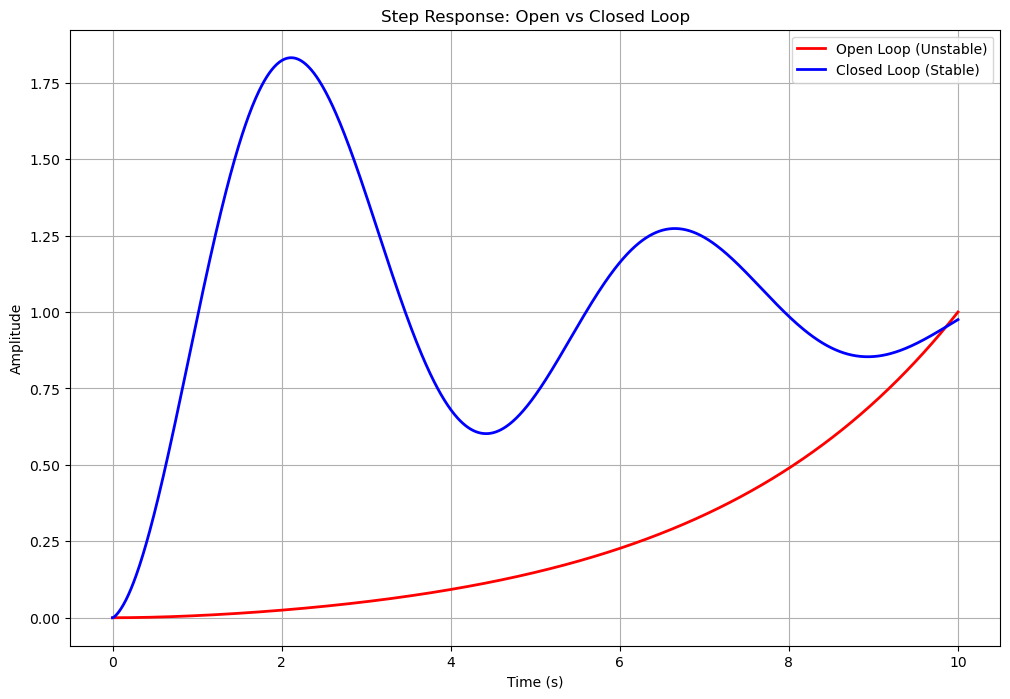

In [20]:
Kp11, Ki11, Kd11 = 2.5, 0.8, 0.2
pid2 = create_pid(Kp11, Ki11, Kd11)
closed_loop2 = control.feedback(pid2 * G2, 1)


print(f"\nPID Parameters for G1: Kp={Kp11}, Ki={Ki11}, Kd={Kd11}")
print("Closed-loop poles for G1:", control.poles(closed_loop2))
print("Closed-loop stability:", "Stable" if is_system_stable(closed_loop2) else "Unstable")


plt.figure(figsize=(12, 8))
t_open, y_open = control.step_response(G2, T=np.linspace(0, 10, 1000))
t_closed, y_closed = control.step_response(closed_loop2, T=np.linspace(0, 10, 1000))
y_normalized = y_open / np.max(np.abs(y_open)) if np.max(np.abs(y_open)) != 0 else y_out
plt.plot(t_open, y_normalized, 'r-', linewidth=2, label='Open Loop (Unstable)')
plt.plot(t_closed, y_closed, 'b-', linewidth=2, label='Closed Loop (Stable)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Step Response: Open vs Closed Loop')
plt.legend()
plt.grid(True)